<a href="https://colab.research.google.com/github/paulacca467/pub_selci/blob/main/correcoes_corrente_varios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install cartopy
!pip install cmocean

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 6.9 MB/s eta 0:00:00


In [2]:
!pip install utide

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.3/75.3 kB 2.6 MB/s eta 0:00:00


In [3]:
!pip install basemap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 732.3 kB/s eta 0:00:00
  Attempting uninstall: pyshp
    Found existing installation: pyshp 3.0.3
    Uninstalling pyshp-3.0.3:
      Successfully uninstalled pyshp-3.0.3
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0


In [78]:
#!/usr/bin/env python3.7
#coding: utf8
# Developed by: Paula Birocchi paula.birocchi@gmail.com
# Applying Method of Joyce (Silver Matrix - LAPECO ADCP course)
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import sys, os
sys.path.append('/content/drive/MyDrive/PUB_SELCI/scripts_for_ADCP')
sys.path.append('/content/drive/MyDrive/PUB_SELCI/scripts_for_ADCP/cmocean-master')
import pandas as pd
import numpy as np
import utide as ut
from scipy import interpolate
import matplotlib.dates as mdates
import xarray as xr
import funcoes
import decomp
import scipy.io
import cmocean
import datetime as dt
import glob
import matplotlib as mpl
import numpy.matlib as npmat
from mpl_toolkits.basemap import Basemap
from matplotlib.collections import PatchCollection
import coastline as fcoastline
import scipy.io as sci
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

# load local coastline
# arquivo de polígonos separados por uma linha "       NaN       NaN"
coastline = np.loadtxt('/content/drive/MyDrive/PUB_SELCI/LC-Cananeia_2.txt')
loncoast1 = coastline[:,0]
latcoast1 = coastline[:,1]





In [79]:

fatias = {
        'C411912181101': [1, None],
    'C421912181133': [1, -2],
    'C431912181223': [1, -1],
    'C441912181300': [2, -2],
    'C451912181340': [3, -3],
    'C461912181508': [4, -3],
    'C471912181546': [3, -3],
    'C481912181621': [2, -3],
    'C491912181659': [2, -3],
    'C491912181705': [3, -5],
    'C491912181741': [2, -3],
    'C491912181855': [3, -2],
    'C491912181936': [3, -1],
    'C131912171124': [1, None],
    'C161912171636': [1, None],
    'C171912171808': [1, None],
    'C181912171935': [1, -1],
    'C191912172020': [1, None],
    'C191912172151': [2, None],
    'C11912170955': [None, -1],
    'C221912171057': [1, None],
    'C231912171148': [1, None],
    'C241912171248': [1, None],
    'C251912171603': [None, -2],
    'C261912171743': [4, -3],
    'C271912171835': [5, -3],
    'C281912171956': [3, -2],
    'C291912172113': [2, -3],
    'C291912172226': [5, -1],
    'C311912181043': [0, 2],
    'C321912181120': [0, 4],
    'C331912181209': [0, 5],
    'C341912181247': [2, 5],
    'C351912181320': [0, 2],
    'C361912181449': [1, 2],
    'C361912181454': [1, 4],
    'C371912181530': [0, 3],
    'C381912181604': [0, 3],
    'C391912181642': [0, 2],
    'C391912181645': [-3, None],
    # 'C391912181721': [0, 2],
    'C391912181830': [0, 3],
    'C391912181838': [0, 2],
    'C391912181920': [0, 5]
}


In [80]:
## GET DATA: ###
# Escolha o local do transecto:
locais = ['nextbasecananeia','desembocaduracananeia','transversal_estuary_iguape', 'valogrande'];
local = locais[1];
## Abrindo pastas e definindo profundidade das celulas do ADP, lat e long para plot:
if local  == 'nextbasecananeia':
	      pasta2='/content/drive/MyDrive/PUB_SELCI/cananeia/campo_dezembro_2019/dados_ADCP/ADCP/ADCP_dados_selecionados/next_base_dados_selecionados/'
	      z = np.arange(2,18);
	      latf = -25.016111
	      lonf =  -47.922711
if local  == 'desembocaduracananeia':
        pasta2='/content/drive/MyDrive/PUB_SELCI/cananeia/campo_dezembro_2019/dados_ADCP/ADCP/ADCP_dados_selecionados/desembocadura_cananeia_dados_selecionados/'
        z = np.arange(2,23);
        latf = -25.056857;
        lonf = -47.912767;
if local == 'transversal_estuary_iguape':
        pasta2 ='/content/drive/MyDrive/PUB_SELCI/cananeia/campo_dezembro_2019/dados_ADCP/ADCP/ADCP_dados_selecionados/transversal_estuary_dados_selecionados/';
        z = np.arange(2,16);
        latf = -24.706237;
        lonf =  -47.543533;
if local == 'valogrande':
        pasta2 ='/content/drive/MyDrive/PUB_SELCI/cananeia/campo_dezembro_2019/dados_ADCP/ADCP/ADCP_dados_selecionados/river_valogrande_dados_selecionados/'
        z = np.arange(2,9);
        latf = -24.714309
        lonf = -47.564286

decl_mag= -20.71;#Estuario de Cananeia Iguape dez/2019



In [81]:
import os
import numpy as np

# Lista para armazenar dados por transecto
all_transect_data = []

my_dirs = [d for d in os.listdir(pasta2) if os.path.isdir(os.path.join(pasta2, d))]
my_dirs=sorted(my_dirs)
for K in np.arange(0,len(my_dirs)):
    pasta = pasta2+my_dirs[K]+'/'+my_dirs[K]
    ## Bottom Track:
    bt=np.loadtxt(pasta+'.btk')
    #Pegando profundidade:
    prof = bt[:,1:4];
    # Fazendo média da profundidade dos 3 beams:
    medprof = np.nanmean(prof,axis=1)
    #Pegando velocidade U (leste-oeste) e V (norte-sul)  do bottom track:
    btu=bt[:,4];
    btv=bt[:,5];
    ##GPS :
    gps = np.loadtxt(pasta+'.gps')
    # Extract lat/lon from GPS data for this transect
    transect_lats = gps[:, 2] # Assuming column 2 is latitude
    transect_lons = gps[:, 3] # Assuming column 3 is longitude

    #Pegando velocidade U (leste-oeste) e V (norte-sul)  do GPS:
    gpsu=gps[:,7];
    gpsv=gps[:,8];
    #Pegando velocidade U e V medidas pelo ADP:
    ve = np.loadtxt(pasta+'.ve')
    vn = np.loadtxt(pasta+'.vn')
    # removendo primeira coluna (referente ao numero do perfil):
    ve = ve[:,1:];
    vn=vn[:,1:];
    # removendo valores espurios do fundo oceanico:
    ve[ve==3276.7]=np.nan;
    vn[vn==3276.7]=np.nan;
    # passando para m/s:
    ve = ve/100;
    vn = vn/100;


    nome_transecto = my_dirs[K]
    regra = fatias.get(nome_transecto)


    if regra:
        start, end = regra

        ve = ve[start:end, :]
        vn = vn[start:end, :]
        medprof = medprof[start:end]
        btu = btu[start:end]
        btv = btv[start:end]
        gpsu = gpsu[start:end]
        gpsv = gpsv[start:end]
        transect_lats = transect_lats[start:end]
        transect_lons = transect_lons[start:end]


    if nome_transecto == 'C271912171835':
        pass

    if nome_transecto == 'C391912181721':

        indices_desejados = [0, 2]
        ve = ve[indices_desejados, :]
        vn = vn[indices_desejados, :]
        medprof = medprof[indices_desejados]
        btu = btu[indices_desejados]
        btv = btv[indices_desejados]
        gpsu = gpsu[indices_desejados]
        gpsv = gpsv[indices_desejados]
        transect_lats = transect_lats[indices_desejados]
        transect_lons = transect_lons[indices_desejados]

    # Calcula lat/lon media
    mean_transect_lat = np.nanmean(transect_lats)
    mean_transect_lon = np.nanmean(transect_lons)


    # Application of Method of Joyce (1989):###############
    #tan(alpha) =< ubt*vsh - vbt*ush>/<ubt*ush + vbt*vsh>
    #1 + beta  = [<ush^2 + vsh^2>/<ubt^2+ vbt^2>]^1/2
    arco=np.nanmean((btu * gpsv) - (btv * gpsu))/np.nanmean((btu * gpsu) + (btv * gpsv)); # right side of equation for alpha
    alpha = np.arctan(arco); # em radianos!
    rightbeta = np.sqrt(np.nanmean(gpsu**2 + gpsv**2)/np.nanmean(btu**2 + btv**2)) # right side of equation for beta
    beta = rightbeta - 1; # em radianos!
    # Corrigindo velocidades U e V (ve e vn):
    veori = ve; # velocidade leste-oeste original ADP
    vnori = vn; # velocidade norte-sul original ADP
    #ucorr = [1 + beta] * ve * np.cos(alpha) - vn * np.sin(alpha)
    #vcorr = [1 + beta] * ve * np.sin(alpha) + vn * np.cos(alpha)
    ve = (1 + beta) * (veori*np.cos(alpha) - vnori*np.sin(alpha));
    vn = (1 + beta) * (veori*np.sin(alpha) + vnori*np.cos(alpha));
    ##################################################################

    if nome_transecto == 'C351912181320' or nome_transecto == 'C391912181838':
        pass
    else:
        ve = -ve
        vn = -vn

    # Calcula magnitude e direcao com declinacao magnetica:
    mag = np.zeros(ve.shape)*np.nan;
    direcao = np.zeros(ve.shape)*np.nan;
    for m in np.arange(0,ve.shape[0]):
        for n in np.arange(0,ve.shape[1]):
            mag[m,n],direcao[m,n] = decomp.uv2intdir(ve[m,n],vn[m,n],decl_mag,0);

    #calcula VE e VN com declinacao magnetica para plot:
    veplot,vnplot = decomp.intdir2uv(mag,direcao,0,0);

    # Perfil mais profundo do transecto:
    vnprof=vnplot[np.where(medprof==np.nanmax(medprof)),:]
    veprof=veplot[np.where(medprof==np.nanmax(medprof)),:]
    magprof=mag[np.where(medprof==np.nanmax(medprof)),:]
    magprof=magprof[~np.isnan(magprof)];
    if len(vnprof.shape)!=1:
        vnprof = np.nanmean(vnprof,axis=0)
    veprof= np.nanmean(veprof,axis=0)
    vnprof2=np.squeeze(vnprof);
    veprof2=np.squeeze(veprof);
    # Calcula velocidade media para cada celula (profundidade):
    vnplotmean = np.nanmean(vnplot,axis=0) ;
    veplotmean = np.nanmean(veplot,axis=0);
    magmean = np.nanmean(mag,axis=0);
    # Removendo nans (valores no fundo)
    vnplotmean = vnplotmean[~np.isnan(vnplotmean)]
    veplotmean = veplotmean[~np.isnan(veplotmean)]
    magplotmean = magmean[~np.isnan(magmean)];
    vnplotmean2 = np.nanmean(vnplotmean)
    veplotmean2 = np.nanmean(veplotmean)
    magmean2 = np.nanmean(magmean)


    transect_data = {
        'lonf': mean_transect_lon,
        'latf': mean_transect_lat,
        'veplot': veplot,
        'vnplot': vnplot,
        'veprof2': veprof2,
        'vnprof2': vnprof2,
        'veplotmean2': veplotmean2,
        'vnplotmean2': vnplotmean2,
        'mag': mag,
        'magprof': magprof,
        'magplotmean': magplotmean,
        'transect_name': my_dirs[K],
        'transect_lats_sliced': transect_lats,
        'transect_lons_sliced': transect_lons,
        'medprof_sliced': medprof
    }


    all_transect_data.append(transect_data)


/tmp/ipykernel_1445/4151387335.py:120: RuntimeWarning: Mean of empty slice
  vnprof = np.nanmean(vnprof,axis=0)
/tmp/ipykernel_1445/4151387335.py:121: RuntimeWarning: Mean of empty slice
  veprof= np.nanmean(veprof,axis=0)
/tmp/ipykernel_1445/4151387335.py:125: RuntimeWarning: Mean of empty slice
  vnplotmean = np.nanmean(vnplot,axis=0) ;
/tmp/ipykernel_1445/4151387335.py:126: RuntimeWarning: Mean of empty slice
  veplotmean = np.nanmean(veplot,axis=0);
/tmp/ipykernel_1445/4151387335.py:127: RuntimeWarning: Mean of empty slice
  magmean = np.nanmean(mag,axis=0);


In [82]:
num_transects = len(all_transect_data)
num_cols = int(np.ceil(np.sqrt(num_transects)))
num_rows = int(np.ceil(num_transects / num_cols))


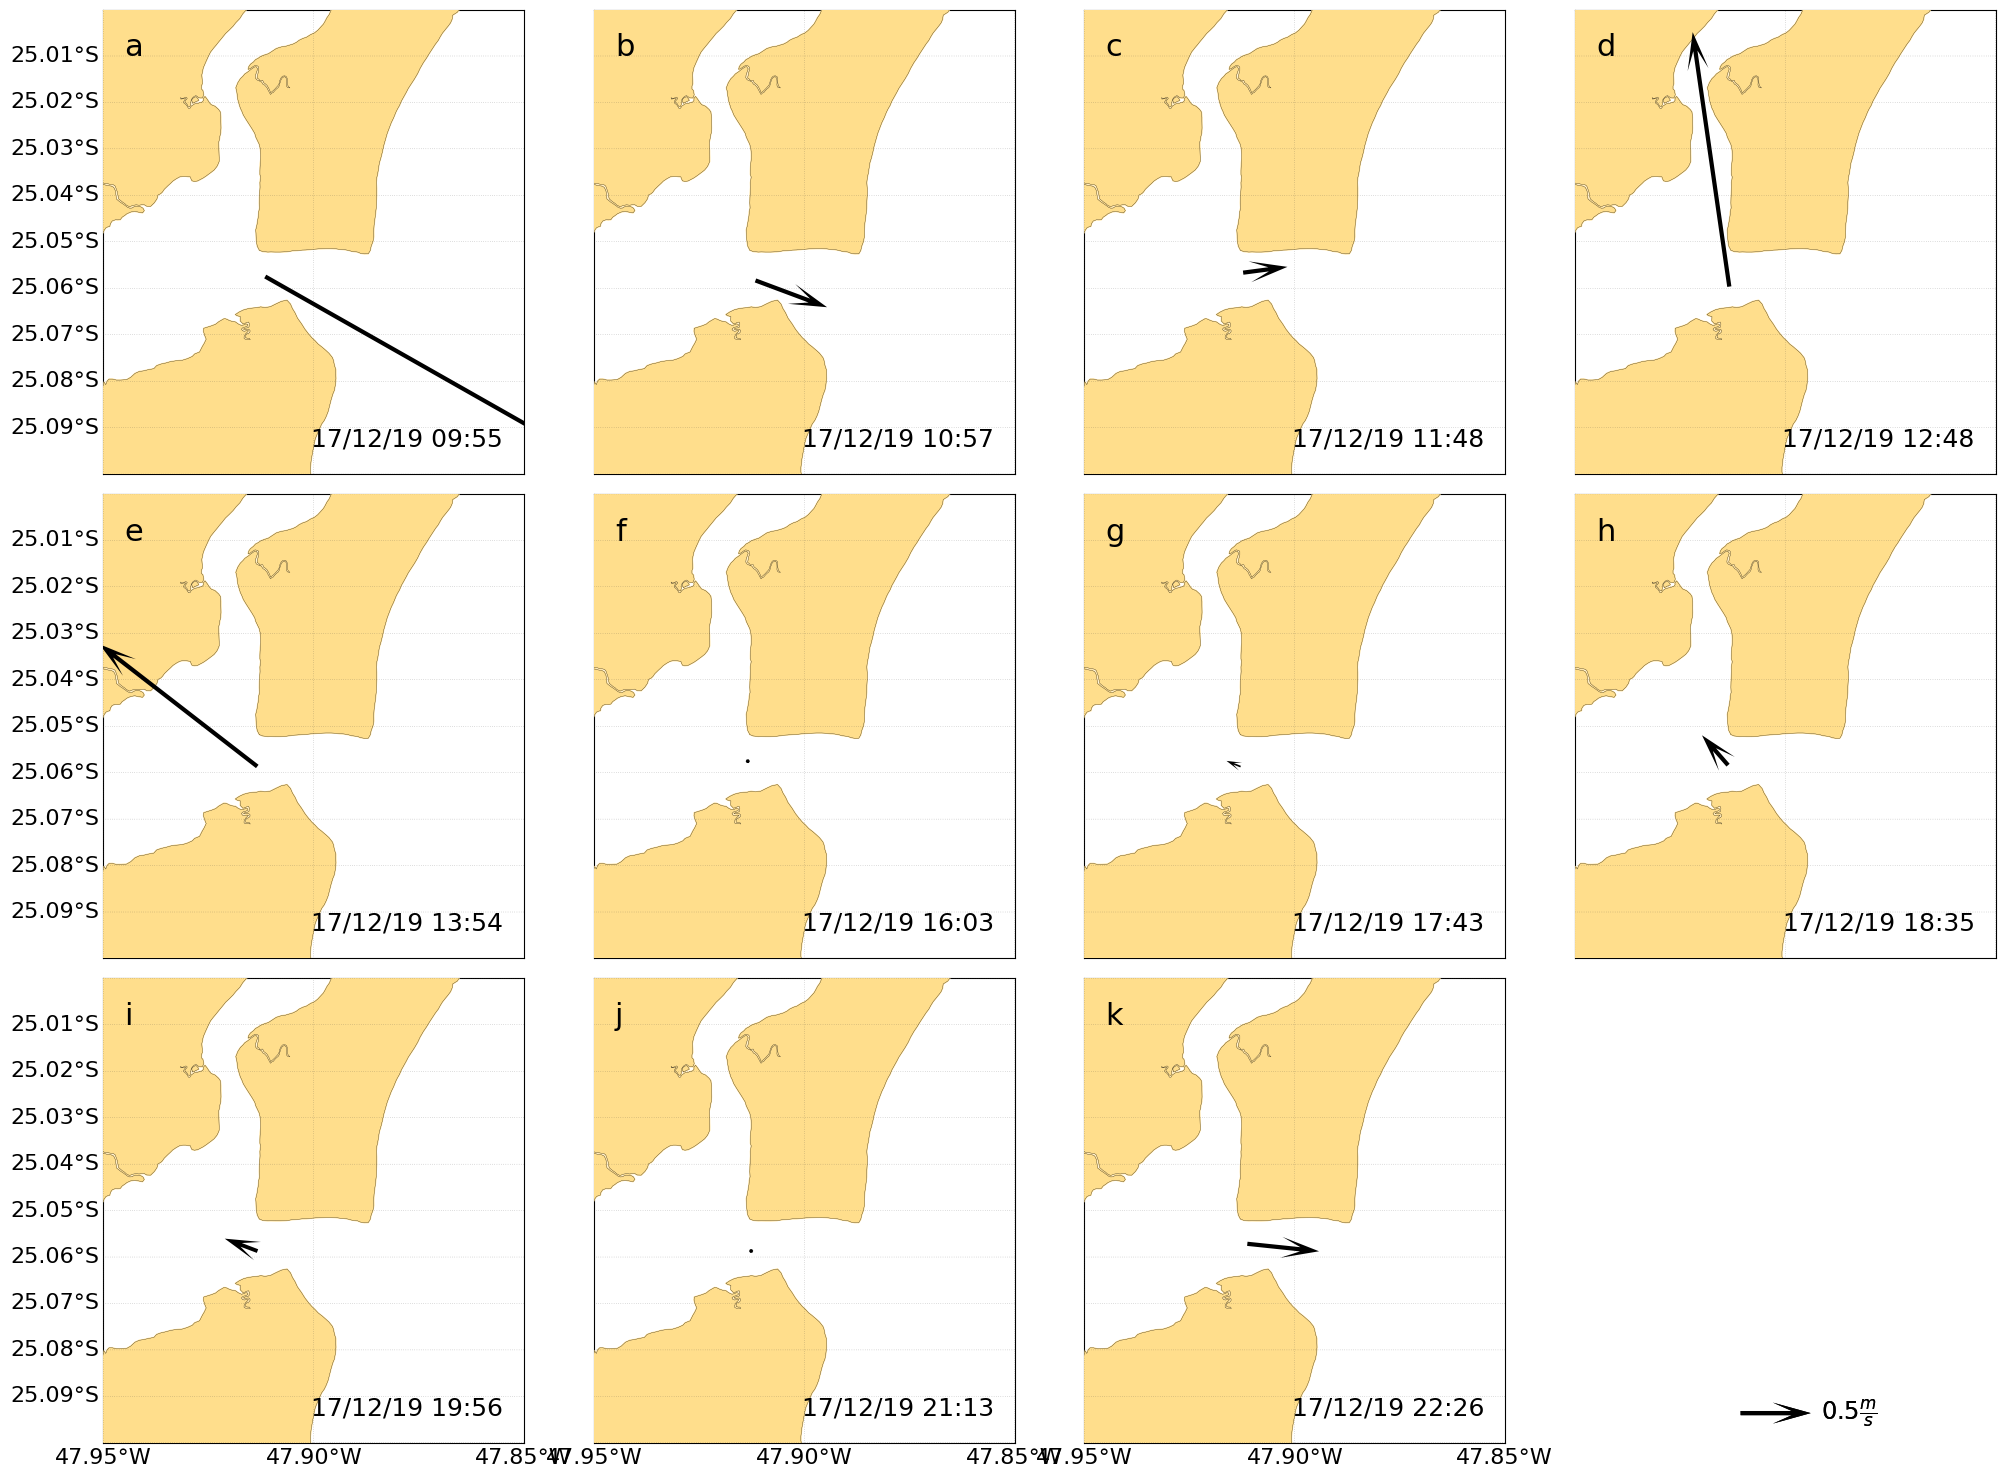

In [83]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.collections import PatchCollection
import numpy as np

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 5), sharex=False, sharey=False)
axes = axes.flatten()

# Initialize Q_subplot to None or a dummy value
Q_subplot = None

for i, transect_data in enumerate(all_transect_data):
    ax = axes[i]

    # Extract stored variables
    veplotmean2 = transect_data['veplotmean2']
    vnplotmean2 = transect_data['vnplotmean2']
    magplotmean = transect_data['magplotmean']
    transect_name = transect_data['transect_name']
    transect_lats_sliced = transect_data['transect_lats_sliced']
    transect_lons_sliced = transect_data['transect_lons_sliced']
    medprof_sliced = transect_data['medprof_sliced']

    # Determine plotting coordinates for the arrow based on the midpoint of the sliced transect
    if len(transect_lats_sliced) > 0:
        mid_idx = len(transect_lats_sliced) // 2
        arrow_lon = transect_lons_sliced[mid_idx]
        arrow_lat = transect_lats_sliced[mid_idx]
    else:
        # Fallback to the mean if sliced data is empty
        arrow_lon = transect_data['lonf']
        arrow_lat = transect_data['latf']

    # Explicitly shift the arrow a bit to the left as requested by the user
    if local == 'valogrande':
      arrow_lon -= 0.002  # Adjust this value as needed for the desired shift

    # Use fixed coordinates for the map extent based on the global 'local' variable
    if local == 'transversal_estuary_iguape':
        lai_map = -24.715
        lae_map = -24.69
        loi_map = -47.55
        loe_map = -47.52
    elif local == 'valogrande':
        lai_map = -24.725
        lae_map = -24.70
        loi_map = -47.57
        loe_map = -47.54
    elif local == 'nextbasecananeia':
        lai_map = -25.035
        lae_map = -25.00
        loi_map = -47.93
        loe_map = -47.90

    elif local == 'desembocaduracananeia' and nome_transecto == 'C11912170955':
        lai_map = -25.15
        lae_map = -25.00
        loi_map = -47.95
        loe_map = -47.60
    elif local == 'desembocaduracananeia':
        lai_map = -25.10
        lae_map = -25.00
        loi_map = -47.95
        loe_map = -47.85
    else:
        # Fallback or error if 'local' is not recognized
        print(f"Warning: 'local' variable '{local}' not recognized for map extent. Using default dynamic extent.")
        buffer = 0.02 # degrees buffer around the transect's mean lat/lon
        lai_map = transect_data['latf'] - buffer # Use mean from transect_data as fallback
        lae_map = transect_data['latf'] + buffer
        loi_map = transect_data['lonf'] - buffer
        loe_map = transect_data['lonf'] + buffer

    m = Basemap(projection='merc', llcrnrlat=lai_map, urcrnrlat=lae_map, llcrnrlon=loi_map, urcrnrlon=loe_map, ax=ax)

    # Define meridians and parallels based on the map extent
    # Increased interval to reduce label density and make them less cramped
    #meridians = np.arange(loi_map, loe_map + 0.01, 0.01)
    #parallels = np.arange(lai_map, lae_map + 0.006, 0.006)
    meridians = np.arange(loi_map, loe_map + 0.05, 0.05)
    parallels = np.arange(lai_map, lae_map + 0.01, 0.01)

    meridians_labels = [0, 0, 0, 0]
    parallels_labels = [0, 0, 0, 0]

    # Show labels only on the bottom row for meridians
    if i >= (num_rows - 1) * num_cols:
        meridians_labels[3] = 1 # bottom

    # Show labels only on the left column for parallels
    if i % num_cols == 0:
        parallels_labels[0] = 1 # left

    m.drawmeridians(meridians, labels=meridians_labels, color='0.2', dashes=[2, 6], linewidth=0.2, zorder=95, fmt='%.2f', fontsize=16);
    m.drawparallels(parallels, labels=parallels_labels, color='0.2', dashes=[2, 6], linewidth=0.2, zorder=96, fmt='%.2f', fontsize=16);

    # Project coastline data and plot
    loncoast, latcoast = m(loncoast1, latcoast1)
    patches = fcoastline.patches(loncoast, latcoast)
    collection = PatchCollection(patches)
    m.plot(loncoast, latcoast, color='black', linewidth=.2, zorder=98);
    ax.add_collection(collection)
    collection.set_color([1, 0.87, 0.55, 1])
    collection.set_zorder(3);

    # Plot mean vertical velocity vector
    Q_subplot = m.quiver([arrow_lon], [arrow_lat], [veplotmean2], [vnplotmean2], latlon=True, scale=3, zorder=99, width=0.01, headwidth=5, headlength=9)

    # Add subplot label (e.g., 'a', 'b', 'c')
    label = chr(ord('a') + i)
    ax.text(0.05, 0.95, label, transform=ax.transAxes, fontsize=22, verticalalignment='top')

    # Add transect name and title
    date_time_str = transect_name[-6:-4] + '/' + transect_name[-8:-6] + '/' + transect_name[-10:-8] + ' ' + transect_name[-4:-2] + ':' + transect_name[-2:]
    ax.text(0.95, 0.05, date_time_str, fontsize=18, transform=ax.transAxes, horizontalalignment='right', verticalalignment='bottom')
    #ax.set_title('v surf =%2.2f' % magplotmean[0] + ' m/s, v bot=%2.2f m/s' % magplotmean[-1], fontsize=10)

# Remove any unused subplots
for i in range(num_transects, num_rows * num_cols):
    fig.delaxes(axes[i])

# Add a single quiver key for the entire figure if Q_subplot was created
if Q_subplot:
    qk_y_position = 0.05 # Default position
    if local == 'valogrande': #or 'transversal_estuary_iguape':
        qk_y_position = 0.03 # Slightly lower for 'valogrande'

    fig.add_artist(plt.quiverkey(Q_subplot, 0.9, qk_y_position, 0.5, r'$0.5 \frac{m}{s}$', labelpos='E', coordinates='figure', fontproperties={'size': 'xx-large'}))

plt.tight_layout(h_pad=0.5, w_pad=0.2)
plt.savefig(str(local) + '_grid.png', bbox_inches='tight', dpi=300)

# Close the figure
#plt.close('all')

In [84]:
#!zip zoom_grids.zip *_grid.png

In [85]:
import pandas as pd
import numpy as np

# 1. Create an empty list to store dictionaries
transect_velocities = []

# 2. Loop through each transect_data dictionary in the all_transect_data list
# Note: The 'all_transect_data' variable is expected to be defined from a previous cell's execution.
for transect_data in all_transect_data:
    # 3. Inside the loop, extract the required values
    transect_name = transect_data['transect_name']
    veplotmean2 = transect_data['veplotmean2']
    vnplotmean2 = transect_data['vnplotmean2']

    # magplotmean is an array, take the first element as per context (e.g., v surf) or mean if more general
    # Assuming the request implies the mean of the magplotmean if it's an array, or the single value if it's scalar
    magplotmean_value = transect_data['magplotmean']
    if isinstance(magplotmean_value, np.ndarray):
        if magplotmean_value.size > 0:
            magplotmean = np.nanmean(magplotmean_value) # Take the mean if it's an array
        else:
            magplotmean = np.nan # Handle empty array case
    else:
        magplotmean = magplotmean_value # Use directly if it's scalar

    # 4. Create a dictionary for the current transect and append it to the list
    transect_info = {
        'Transect Name': transect_name,
        'Mean VE (m/s)': veplotmean2,
        'Mean VN (m/s)': vnplotmean2,
        'Mean Magnitude (m/s)': magplotmean
    }
    transect_velocities.append(transect_info)

# 5. Convert the list of dictionaries into a pandas DataFrame
df_transect_velocities = pd.DataFrame(transect_velocities)

# 6. Print the DataFrame to display the extracted mean velocities
print("Mean Velocities per Transect:")
print(df_transect_velocities.to_markdown(index=False))

Mean Velocities per Transect:
| Transect Name   |   Mean VE (m/s) |   Mean VN (m/s) |   Mean Magnitude (m/s) |
|:----------------|----------------:|----------------:|-----------------------:|
| C11912170955    |      3.09008    |     -1.75253    |               4.00966  |
| C221912171057   |      0.510253   |     -0.190877   |               0.643128 |
| C231912171148   |      0.315814   |      0.0413283  |               0.443458 |
| C241912171248   |     -0.261191   |      1.81421    |               1.87448  |
| C2421912171354  |     -1.12503    |      0.871193   |               1.66904  |
| C251912171603   |     -0.0107753  |      0.0188573  |               0.159798 |
| C261912171743   |     -0.100178   |      0.0407927  |               0.220322 |
| C271912171835   |     -0.185776   |      0.212952   |               0.366568 |
| C281912171956   |     -0.233413   |      0.0885283  |               0.312172 |
| C291912172113   |      0.00346179 |      0.00702054 |               0.208216 

In [86]:
import pandas as pd

df = pd.DataFrame(transect_velocities)
df.to_excel("dados3.xlsx", index=False)

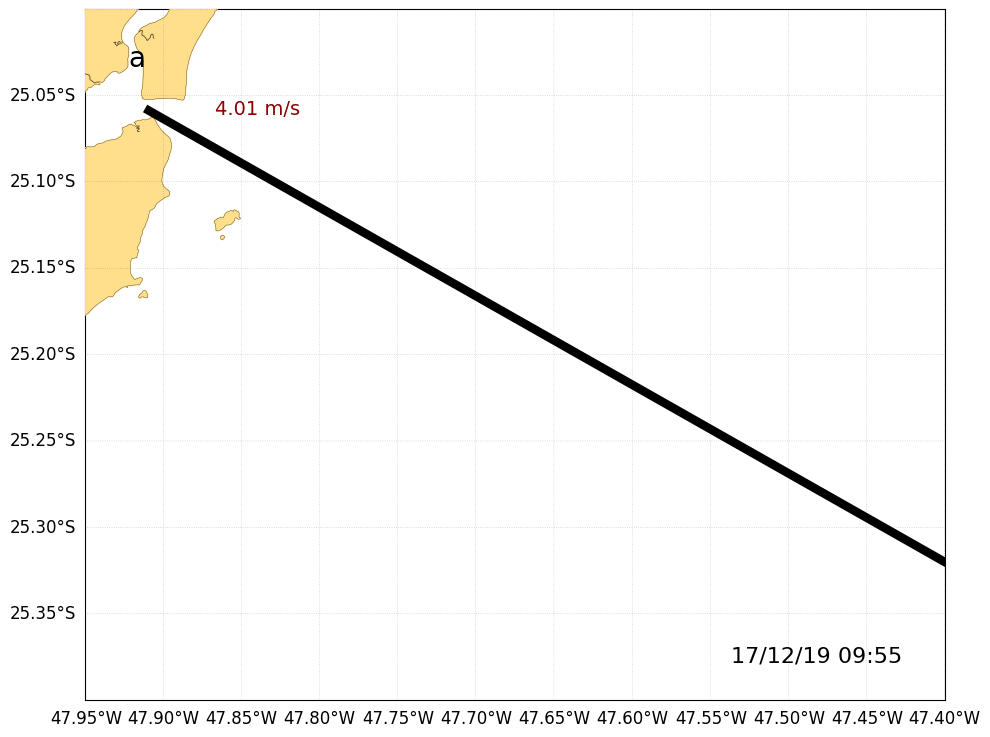

In [94]:
# @title
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.collections import PatchCollection
import numpy as np
import os

# Assuming 'fatias', 'decomp', 'fcoastline', and 'coastline' (np.loadtxt data) are loaded from previous cells.
# If not, ensure relevant imports/definitions are also added here.

# --- Replicate data setup for 'desembocaduracananeia' ---
locais = ['nextbasecananeia','desembocaduracananeia','transversal_estuary_iguape', 'valogrande'];
local = locais[1]; # Set to 'desembocaduracananeia' for this plot

pasta2='/content/drive/MyDrive/PUB_SELCI/cananeia/campo_dezembro_2019/dados_ADCP/ADCP/ADCP_dados_selecionados/desembocadura_cananeia_dados_selecionados/'
z = np.arange(2,23);
latf_global = -25.056857;
lonf_global = -47.912767;
decl_mag= -20.71;

# --- Replicate data processing for the selected local and only the first transect ---
all_transect_data = []
my_dirs = [d for d in os.listdir(pasta2) if os.path.isdir(os.path.join(pasta2, d))]
my_dirs = sorted(my_dirs)

# We only need the first transect to plot 'caixa letra a)'
if not my_dirs:
    print(f"No directories found for local: {local}")
else:
    first_transect_name = my_dirs[0]

    pasta = pasta2 + first_transect_name + '/' + first_transect_name

    ## Bottom Track:
    bt=np.loadtxt(pasta+'.btk')
    prof = bt[:,1:4];
    medprof = np.nanmean(prof,axis=1)
    btu=bt[:,4];
    btv=bt[:,5];

    ##GPS :
    gps = np.loadtxt(pasta+'.gps')
    transect_lats = gps[:, 2]
    transect_lons = gps[:, 3]

    gpsu=gps[:,7];
    gpsv=gps[:,8];

    #Pegando velocidade U e V medidas pelo ADP:
    ve = np.loadtxt(pasta+'.ve')
    vn = np.loadtxt(pasta+'.vn')
    ve = ve[:,1:];
    vn=vn[:,1:];
    ve[ve==3276.7]=np.nan;
    vn[vn==3276.7]=np.nan;
    ve = ve/100;
    vn = vn/100;

    nome_transecto = first_transect_name
    regra = fatias.get(nome_transecto)

    if regra:
        start, end = regra
        ve = ve[start:end, :]
        vn = vn[start:end, :]
        medprof = medprof[start:end]
        btu = btu[start:end]
        btv = btv[start:end]
        gpsu = gpsu[start:end]
        gpsv = gpsv[start:end]
        transect_lats = transect_lats[start:end]
        transect_lons = transect_lons[start:end]

    if nome_transecto == 'C271912171835':
        pass
    if nome_transecto == 'C391912181721':
        indices_desejados = [0, 2]
        ve = ve[indices_desejados, :]
        vn = vn[indices_desejados, :]
        medprof = medprof[indices_desejados]
        btu = btu[indices_desejados]
        btv = btv[indices_desejados]
        gpsu = gpsu[indices_desejados]
        gpsv = gpsv[indices_desejados]
        transect_lats = transect_lats[indices_desejados]
        transect_lons = transect_lons[indices_desejados]

    mean_transect_lat = np.nanmean(transect_lats)
    mean_transect_lon = np.nanmean(transect_lons)

    arco=np.nanmean((btu * gpsv) - (btv * gpsu))/np.nanmean((btu * gpsu) + (btv * gpsv));
    alpha = np.arctan(arco);
    rightbeta = np.sqrt(np.nanmean(gpsu**2 + gpsv**2)/np.nanmean(btu**2 + btv**2))
    beta = rightbeta - 1;
    veori = ve;
    vnori = vn;
    ve = (1 + beta) * (veori*np.cos(alpha) - vnori*np.sin(alpha));
    vn = (1 + beta) * (veori*np.sin(alpha) + vnori*np.cos(alpha));

    if nome_transecto == 'C351912181320' or nome_transecto == 'C391912181838':
        pass
    else:
        ve = -ve
        vn = -vn

    mag = np.zeros(ve.shape)*np.nan;
    direcao = np.zeros(ve.shape)*np.nan;
    for m in np.arange(0,ve.shape[0]):
        for n in np.arange(0,ve.shape[1]):
            mag[m,n],direcao[m,n] = decomp.uv2intdir(ve[m,n],vn[m,n],decl_mag,0);

    veplot,vnplot = decomp.intdir2uv(mag,direcao,0,0);

    # Check if medprof is not empty before indexing
    if medprof.size > 0 and not np.all(np.isnan(medprof)):
        max_medprof_idx = np.where(medprof==np.nanmax(medprof))
        vnprof=vnplot[max_medprof_idx,:]
        veprof=veplot[max_medprof_idx,:]
        magprof=mag[max_medprof_idx,:]
        magprof=magprof[~np.isnan(magprof)];

        if len(vnprof.shape)!=1:
            vnprof = np.nanmean(vnprof,axis=0)
        veprof= np.nanmean(veprof,axis=0)
        vnprof2=np.squeeze(vnprof);
        veprof2=np.squeeze(veprof);
    else:
        vnprof2 = np.nan
        veprof2 = np.nan
        magprof = np.array([])

    vnplotmean = np.nanmean(vnplot,axis=0) ;
    veplotmean = np.nanmean(veplot,axis=0);
    magmean = np.nanmean(mag,axis=0);
    vnplotmean = vnplotmean[~np.isnan(vnplotmean)]
    veplotmean = veplotmean[~np.isnan(veplotmean)]
    magplotmean = magmean[~np.isnan(magmean)];
    vnplotmean2 = np.nanmean(vnplotmean) if vnplotmean.size > 0 else np.nan
    veplotmean2 = np.nanmean(veplotmean) if veplotmean.size > 0 else np.nan
    magmean2 = np.nanmean(magmean) if magmean.size > 0 else np.nan

    transect_data = {
        'lonf': mean_transect_lon,
        'latf': mean_transect_lat,
        'veplot': veplot,
        'vnplot': vnplot,
        'veprof2': veprof2,
        'vnprof2': vnprof2,
        'veplotmean2': veplotmean2,
        'vnplotmean2': vnplotmean2,
        'mag': mag,
        'magprof': magprof,
        'magplotmean': magplotmean,
        'transect_name': first_transect_name,
        'transect_lats_sliced': transect_lats,
        'transect_lons_sliced': transect_lons,
        'medprof_sliced': medprof
    }

    # --- Plotting the single transect ---
    fig, ax = plt.subplots(1, 1, figsize=(10, 10)) # Single plot, larger figure size

    veplotmean2 = transect_data['veplotmean2']
    vnplotmean2 = transect_data['vnplotmean2']
    magplotmean = transect_data['magplotmean']
    transect_name = transect_data['transect_name']
    transect_lats_sliced = transect_data['transect_lats_sliced']
    transect_lons_sliced = transect_data['transect_lons_sliced']
    medprof_sliced = transect_data['medprof_sliced']

    if len(transect_lats_sliced) > 0:
        mid_idx = len(transect_lats_sliced) // 2
        arrow_lon = transect_lons_sliced[mid_idx]
        arrow_lat = transect_lats_sliced[mid_idx]
    else:
        arrow_lon = transect_data['lonf']
        arrow_lat = transect_data['latf']

    # Use fixed coordinates for the map extent for 'desembocaduracananeia' (wider view)
    lai_map = -25.40
    lae_map = -25.00
    loi_map = -47.95
    loe_map = -47.40

    m = Basemap(projection='merc', llcrnrlat=lai_map, urcrnrlat=lae_map, llcrnrlon=loi_map, urcrnrlon=loe_map, ax=ax)

    # Define meridians and parallels for better readability on a larger map
    meridians = np.arange(loi_map, loe_map + 0.05, 0.05)
    parallels = np.arange(lai_map, lae_map + 0.05, 0.05)

    m.drawmeridians(meridians, labels=[0,0,0,1], color='0.2', dashes=[2, 6], linewidth=0.2, zorder=95, fmt='%.2f', fontsize=12);
    m.drawparallels(parallels, labels=[1,0,0,0], color='0.2', dashes=[2, 6], linewidth=0.2, zorder=96, fmt='%.2f', fontsize=12);

    # Project coastline data and plot (assuming 'coastline' and 'fcoastline' are available globally)
    loncoast, latcoast = m(coastline[:,0], coastline[:,1])
    patches = fcoastline.patches(loncoast, latcoast)
    collection = PatchCollection(patches)
    m.plot(loncoast, latcoast, color='black', linewidth=.2, zorder=98);
    ax.add_collection(collection)
    collection.set_color([1, 0.87, 0.55, 1])
    collection.set_zorder(3);

    # Plot mean vertical velocity vector
    Q_subplot = m.quiver([arrow_lon], [arrow_lat], [veplotmean2], [vnplotmean2], latlon=True, scale=3, zorder=99, width=0.01, headwidth=5, headlength=9)

    # Add subplot label 'a'
    label = 'a'
    ax.text(0.05, 0.95, label, transform=ax.transAxes, fontsize=20, verticalalignment='top')

    # Add transect name and title
    date_time_str = transect_name[-6:-4] + '/' + transect_name[-8:-6] + '/' + transect_name[-10:-8] + ' ' + transect_name[-4:-2] + ':' + transect_name[-2:]
    ax.text(0.95, 0.05, date_time_str, fontsize=16, transform=ax.transAxes, horizontalalignment='right', verticalalignment='bottom')

    # Add magnitude text next to the arrow
    # Convert lat/lon to map coordinates for accurate text placement
    x_text, y_text = m(arrow_lon, arrow_lat)
    # Adjust position to be slightly offset from the arrow head
    ax.text(x_text + 5000, y_text, f'{magmean2:.2f} m/s', fontsize=14, color='darkred', transform=ax.transData, verticalalignment='center', zorder=100)

    # Add a single quiver key
    qk_y_position = 0.05
    fig.add_artist(plt.quiverkey(Q_subplot, 0.9, qk_y_position, 0.5, r'$0.5 \frac{m}{s}$', labelpos='E', coordinates='figure', fontproperties={'size': 'large'}))

    plt.tight_layout()
    plt.savefig(str(local) + '_single_grid_a.png', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close('all')